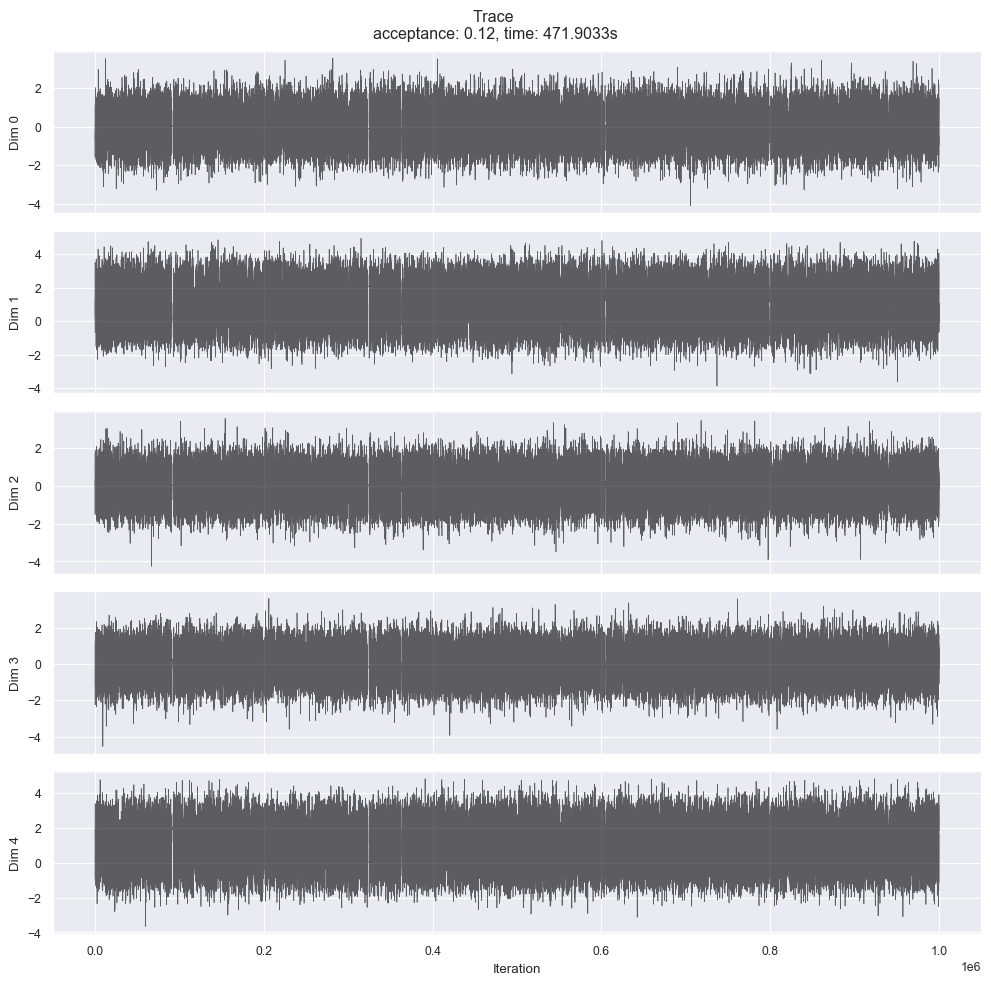

MALA acceptance Rate: 0.12
time elapsed: 471.9033478749989 to iteration 999999
[[-0.65877962  1.37695304  0.29526283 -1.22965507  1.98856726  0.36880452]
 [-0.29275727  1.20502279  0.05715584  0.03117988  0.61040004  0.88012349]
 [ 0.92160992  3.48750829  0.4985927   0.94451087  0.20585323 -0.40258434]
 ...
 [-0.46222676 -0.09842217  0.41216452 -0.26392879  1.67959161  0.16712775]
 [-0.46222676 -0.09842217  0.41216452 -0.26392879  1.67959161  0.16712775]
 [-0.46222676 -0.09842217  0.41216452 -0.26392879  1.67959161  0.16712775]]
Finished Sampling


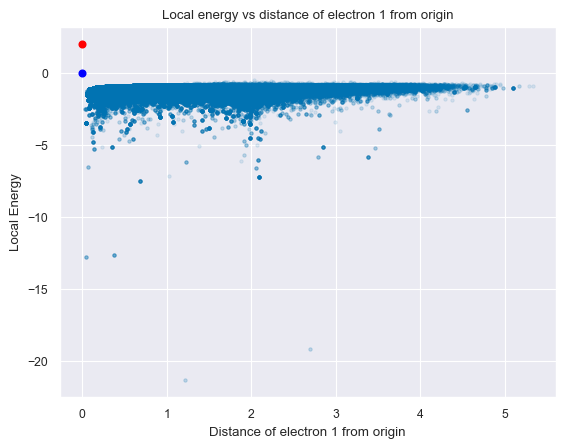

local energy: [-1.17450378 -1.36485626 -0.97211304 ... -1.25708939 -1.25708939
 -1.25708939]
Expected Energy: -1.1770719039548696


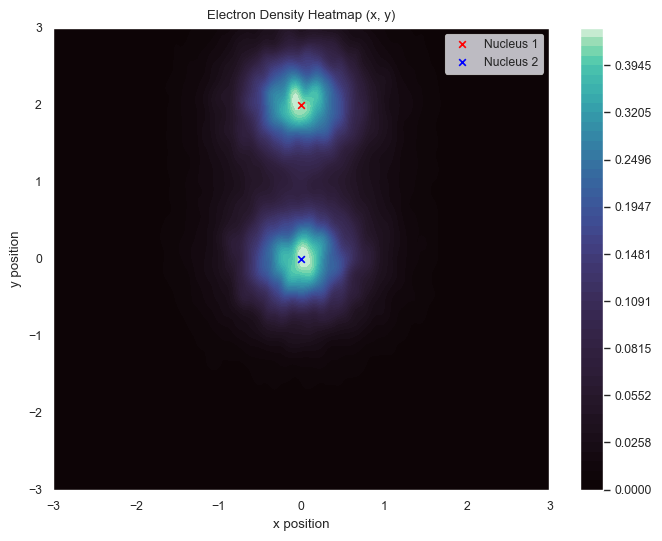

In [ ]:
"""
Simulation of the hydrogen molecule using variational Monte Carlo methods.
Louis Liu 28/11
"""
import numpy as np
from modules.helpers import hydrogen_molecule_helpers as hlp
from modules.differentiators import double_central_difference
from modules.function_sampling import metropolis_hastings, MALA
from modules.minimisers import hydrogen_molecule_minimisers as min
import matplotlib.pyplot as plt
eps = 1e-15


class h2_wavefunction:
    def __init__(self, thetas: np.ndarray, q1: np.ndarray, q2: np.ndarray):
        """
        Constructor
        Parameters:
            theta (np.ndarray): Variational parameters [theta1, theta2, theta3].
            q1 (np.ndarray): Position of the first nucleus.
            q2 (np.ndarray): Position of the second nucleus.
        """
        q1, q2 = np.array(q1), np.array(q2)
        if len(q1.shape) == 1:
            q1, q2 = np.asarray([q1]), np.asarray([q2])

        self.f = hlp.anstatz(thetas, q1, q2)
        self._thetas = thetas
        self._q1 = q1
        self._q2 = q2

    def psi(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The value of the trial wavefunction at the given position(s)
        """
        return self.f(r1, r2)

    def probability_density(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The probability density of the trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The probability density at the given position(s)
        """
        return np.abs(self.f(r1, r2))**2

    def theta(self) -> np.ndarray:
        """
        Returns the theta parameter of the wavefunction
        Returns:
            float: the value of theta for the current wavefunction
        """
        return self._thetas

    def local_energy(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray:
        """
        The local energy of the hydrogen molecule trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """

        r1, r2 = np.asarray(r1), np.asarray(r2)
        #  reformat
        if len(r1.shape) == 1:
            r1, r2 = np.asarray([r1]), np.asarray([r2])

        q1 = self._q1
        q2 = self._q2

        #  function to fix r2
        def f_r1(r1):
            return self.psi(r1, r2)

        #  function to fix r1
        def f_r2(r2):
            return self.psi(r1, r2)

        d2f_r1 = double_central_difference(
            f_r1, r1, h=[1e-5, 1e-5, 1e-5], order=8)

        d2f_r2 = double_central_difference(
            f_r2, r2, h=[1e-5, 1e-5, 1e-5], order=8)

        kinetic = - 0.5 / \
            self.psi(r1, r2) * (np.sum(d2f_r1, axis=1) +
                                np.sum(d2f_r2, axis=1))

        #  computes r and subtracts them
        def d(a, b): return np.sqrt(np.sum((a - b)**2, axis=1))

        r1q1, r1q2 = d(r1, q1), d(r1, q2)
        r2q1, r2q2 = d(r2, q1), d(r2, q2)
        r12 = d(r1, r2)
        q1q2 = d(q1, q2)

        potential = - (1/r1q1 + 1/r1q2 + 1/r2q1 + 1/r2q2) \
            + (1/r12) \
            + (1/q1q2)

        return kinetic + potential

    def E_exp(self, r1, r2):
        """
        The energy expecation value of the hydrogen molecule trial wavefunction at given coordinates
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """
        r1, r2 = np.asarray(r1), np.asarray(r2)
        E_ls = self.local_energy(r1, r2)
        return np.mean(E_ls,)


def test_samples():
    q1 = [0, 2, 0]
    q2 = [0, 0, 0]
    wf = h2_wavefunction(thetas=[1., 1., 1.], q1=q1, q2=q2)

    def wrapper(coords):
        coords = np.asarray(coords)
        r1 = coords[:, 0:3]
        r2 = coords[:, 3:6]

        return wf.probability_density(r1, r2)

    def wrapper_grad(coords):
        from modules.differentiators import central_difference

        coords = np.asarray(coords)
        grad = central_difference(wrapper, coords, h=[1e-4]*6, order=2)
        return np.sum(grad, axis=0)

    x_0 = np.ones(6, dtype=float)
    N_s = 1000000
    samples = MALA(wrapper, wrapper_grad, x_0=x_0, N=N_s, timestep=0.5, xmin=[
                   -5] * 6, xmax=[5] * 6, detail=True)
    print(samples)

    print('Finished Sampling')

    r1, r2 = samples[:, 0:3], samples[:, 3:6]
    E_l = wf.local_energy(r1=r1, r2=r2)

    plt.scatter(np.linalg.norm(r1, axis=1), E_l, marker='.', alpha=0.1)
    plt.plot(0, q1[1], 'ro', label='Nucleus 1')
    plt.plot(0, q2[1], 'bo', label='Nucleus 2')
    plt.xlabel("Distance of electron 1 from origin")
    plt.ylabel("Local Energy")
    plt.title("Local energy vs distance of electron 1 from origin")
    plt.show()

    print(f"local energy: {E_l}")
    exp_energy = np.mean(E_l)
    print(f"Expected Energy: {exp_energy}")

    hlp.plot_samples(
        r1, r2, q1=q1, q2=q2, xlim=[-3, 3], ylim=[-3, 3], seaborn=True)
    plt.show()


def test_minimiser():
    q1 = [0, 0, 2]
    q2 = [0, 0, 0]

    minimiser = min.gradient_descent

    thetas_0 = [1.] * 3  #  for minimiser
    theta_min, E_min = minimiser(q1, q2, x_0=thetas_0,
                                 alpha=0.02, stop_tol=None, N_s=10000, detail=True, max_iter=100)

    # theta_min, E_min = min.simulated_annealing(
    #     q1, q2, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=10000, std=0.05, detail=True)
    print(f"minimum theta: {theta_min}, minimum energy: {E_min}")


def ground_state_energies():
    Ns = 100000
    r_0 = np.linspace(0.1, 4., 100)
    q1 = [0.] * 3
    q2 = [[0., 0., i] for i in r_0]

    energies = []
    count = 0
    for q2_i in q2:
        count += 1
        thetas_0 = [1.]*3  #  for minimiser
        # theta_min, E_min = min.simulated_annealing(
        #     q1, q2_i, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=Ns, std=0.05, detail=False)

        theta_min, E_min = min.gradient_descent(
            q1, q2_i, x_0=thetas_0, alpha=0.02, stop_tol=1e-3, N_s=Ns, detail=False, max_iter=100)
        energies.append(E_min)
        if count % 10 == 0:  #  checkpoint at every 10 steps
            np.savetxt(f"output_{Ns}.txt", [energies, r_0[:len(energies)]])

        print(
            f"iteration: {count}, q2: {q2_i}, minimum theta: {theta_min}, minimum energy: {E_min}")

    np.savetxt(f"output_{Ns}.txt", [energies, r_0[:len(energies)]])
    energies = np.array(energies)
    from scipy.optimize import curve_fit
    f = hlp.V_morse
    p_0 = [0.25, 1.3, 1.4]
    fit, cov = curve_fit(f, r_0, energies, p0=p_0)

    plt.plot(r_0, f(r_0, *fit), label='Morse Potential Fit', color='orange')
    plt.plot(r_0, energies, 'o', label='Data')
    plt.xlabel("Distance between nuclei (a.u.)")
    plt.ylabel("Minimum Energy (a.u.)")
    plt.title("Morse Potential Fit to H2 Minimum Energy")
    plt.legend()
    print(
        f"Fitted Parameters: De= {fit[0]}, a= {fit[1]}, re= {fit[2]} \n errors: {np.sqrt(np.diag(cov))}")


if __name__ == '__main__':
    test_samples()

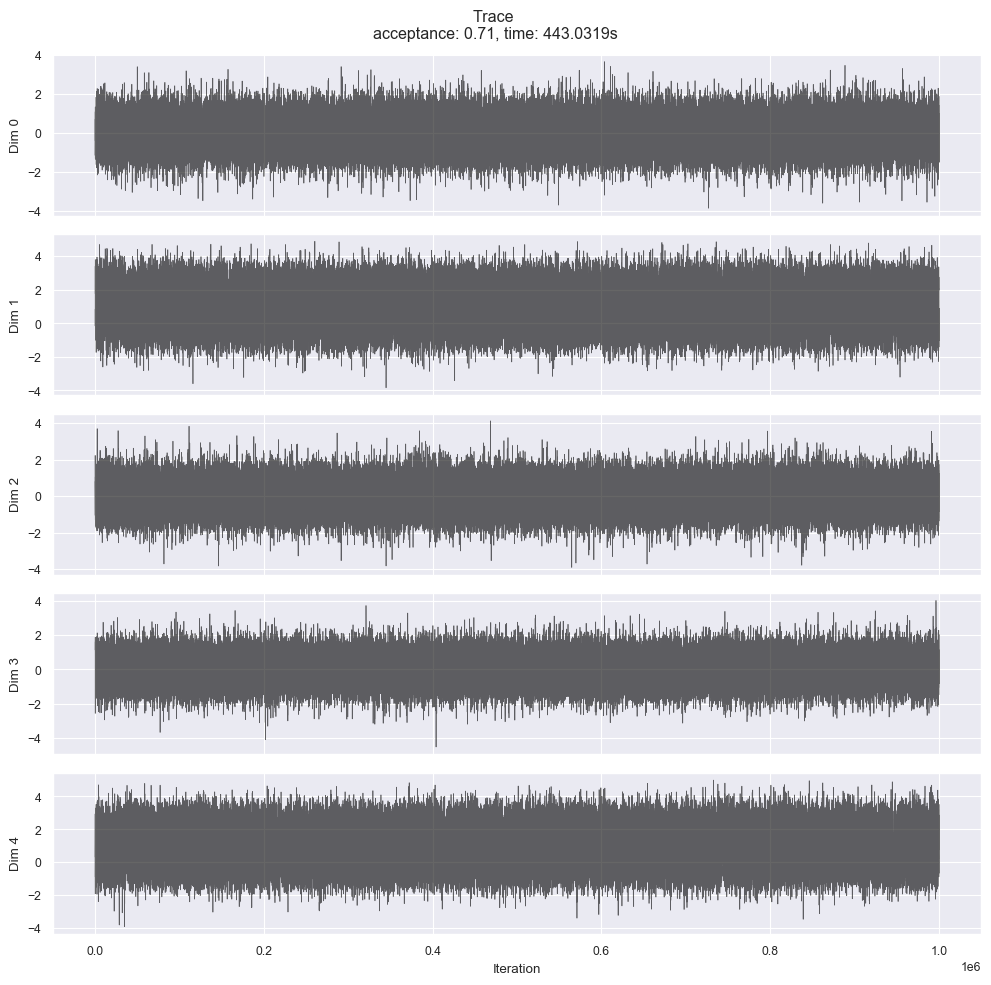

MALA acceptance Rate: 0.71
time elapsed: 443.0319432499964 to iteration 999999
[[ 0.72339038  0.8499665   0.79819295  1.13795591  0.32128572  1.27778664]
 [ 0.43457677  0.48193349  0.03990301  0.65846877  0.92245861  0.93116964]
 [ 0.25271739  0.18744674 -0.24822836  0.20810816  0.7922514   0.98689641]
 ...
 [-0.7337295  -0.26626633 -0.51225444  0.81101367  1.60686892 -0.47375355]
 [-0.93685984 -0.50677338  0.45617385  0.73250839  2.57148652 -0.47834382]
 [-1.4650792  -0.1613368   0.1189911   0.84818352  2.86850286 -0.62384702]]
Finished Sampling


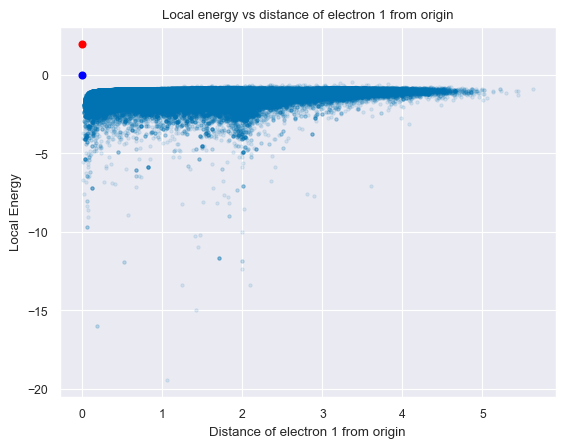

local energy: [-0.92042435 -1.33529942 -1.52364882 ... -1.0741397  -0.92748117
 -0.92799291]
Expected Energy: -1.1777350341829644


<Figure size 800x600 with 0 Axes>

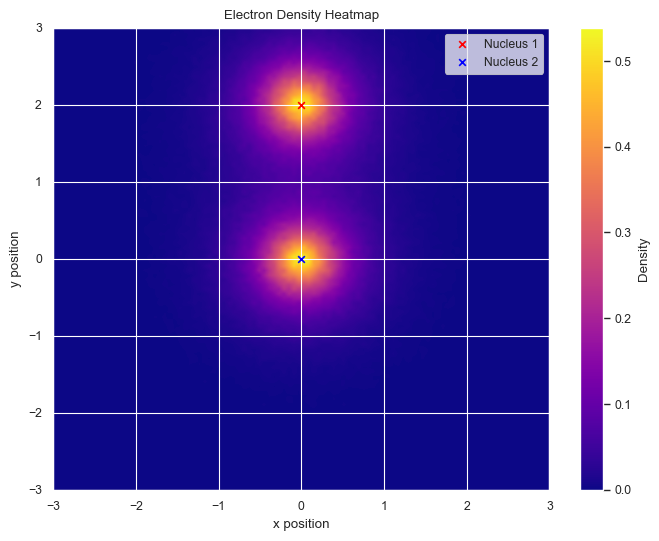

In [ ]:
"""
Simulation of the hydrogen molecule using variational Monte Carlo methods.
Louis Liu 28/11
"""
import numpy as np
from modules.helpers import hydrogen_molecule_helpers as hlp
from modules.differentiators import double_central_difference
from modules.function_sampling import metropolis_hastings, MALA
from modules.minimisers import hydrogen_molecule_minimisers as min
import matplotlib.pyplot as plt
eps = 1e-15


class h2_wavefunction:
    def __init__(self, thetas: np.ndarray, q1: np.ndarray, q2: np.ndarray):
        """
        Constructor
        Parameters:
            theta (np.ndarray): Variational parameters [theta1, theta2, theta3].
            q1 (np.ndarray): Position of the first nucleus.
            q2 (np.ndarray): Position of the second nucleus.
        """
        q1, q2 = np.array(q1), np.array(q2)
        if len(q1.shape) == 1:
            q1, q2 = np.asarray([q1]), np.asarray([q2])

        self.f = hlp.anstatz(thetas, q1, q2)
        self._thetas = thetas
        self._q1 = q1
        self._q2 = q2

    def psi(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The value of the trial wavefunction at the given position(s)
        """
        return self.f(r1, r2)

    def probability_density(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The probability density of the trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The probability density at the given position(s)
        """
        return np.abs(self.f(r1, r2))**2

    def theta(self) -> np.ndarray:
        """
        Returns the theta parameter of the wavefunction
        Returns:
            float: the value of theta for the current wavefunction
        """
        return self._thetas

    def local_energy(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray:
        """
        The local energy of the hydrogen molecule trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """

        r1, r2 = np.asarray(r1), np.asarray(r2)
        #  reformat
        if len(r1.shape) == 1:
            r1, r2 = np.asarray([r1]), np.asarray([r2])

        q1 = self._q1
        q2 = self._q2

        #  function to fix r2
        def f_r1(r1):
            return self.psi(r1, r2)

        #  function to fix r1
        def f_r2(r2):
            return self.psi(r1, r2)

        d2f_r1 = double_central_difference(
            f_r1, r1, h=[1e-5, 1e-5, 1e-5], order=8)

        d2f_r2 = double_central_difference(
            f_r2, r2, h=[1e-5, 1e-5, 1e-5], order=8)

        kinetic = - 0.5 / \
            self.psi(r1, r2) * (np.sum(d2f_r1, axis=1) +
                                np.sum(d2f_r2, axis=1))

        #  computes r and subtracts them
        def d(a, b): return np.sqrt(np.sum((a - b)**2, axis=1))

        r1q1, r1q2 = d(r1, q1), d(r1, q2)
        r2q1, r2q2 = d(r2, q1), d(r2, q2)
        r12 = d(r1, r2)
        q1q2 = d(q1, q2)

        potential = - (1/r1q1 + 1/r1q2 + 1/r2q1 + 1/r2q2) \
            + (1/r12) \
            + (1/q1q2)

        return kinetic + potential

    def E_exp(self, r1, r2):
        """
        The energy expecation value of the hydrogen molecule trial wavefunction at given coordinates
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """
        r1, r2 = np.asarray(r1), np.asarray(r2)
        E_ls = self.local_energy(r1, r2)
        return np.mean(E_ls,)


def test_samples():
    q1 = [0, 2, 0]
    q2 = [0, 0, 0]
    wf = h2_wavefunction(thetas=[1., 1., 1.], q1=q1, q2=q2)

    def wrapper(coords):
        coords = np.asarray(coords)
        r1 = coords[:, 0:3]
        r2 = coords[:, 3:6]

        return wf.probability_density(r1, r2)

    def wrapper_grad(coords):
        from modules.differentiators import central_difference

        coords = np.asarray(coords)
        grad = central_difference(wrapper, coords, h=[1e-4]*6, order=2)
        return np.sum(grad, axis=0)

    x_0 = np.ones(6, dtype=float)
    N_s = 1000000
    samples = MALA(wrapper, wrapper_grad, x_0=x_0, N=N_s, timestep=0.1, xmin=[
                   -5] * 6, xmax=[5] * 6, detail=True)
    print(samples)

    print('Finished Sampling')

    r1, r2 = samples[:, 0:3], samples[:, 3:6]
    E_l = wf.local_energy(r1=r1, r2=r2)

    plt.scatter(np.linalg.norm(r1, axis=1), E_l, marker='.', alpha=0.1)
    plt.plot(0, q1[1], 'ro', label='Nucleus 1')
    plt.plot(0, q2[1], 'bo', label='Nucleus 2')
    plt.xlabel("Distance of electron 1 from origin")
    plt.ylabel("Local Energy")
    plt.title("Local energy vs distance of electron 1 from origin")
    plt.show()

    print(f"local energy: {E_l}")
    exp_energy = np.mean(E_l)
    print(f"Expected Energy: {exp_energy}")

    hlp.plot_samples(
        r1, r2, q1=q1, q2=q2, xlim=[-3, 3], ylim=[-3, 3], seaborn=False)
    plt.show()


def test_minimiser():
    q1 = [0, 0, 2]
    q2 = [0, 0, 0]

    minimiser = min.gradient_descent

    thetas_0 = [1.] * 3  #  for minimiser
    theta_min, E_min = minimiser(q1, q2, x_0=thetas_0,
                                 alpha=0.02, stop_tol=None, N_s=10000, detail=True, max_iter=100)

    # theta_min, E_min = min.simulated_annealing(
    #     q1, q2, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=10000, std=0.05, detail=True)
    print(f"minimum theta: {theta_min}, minimum energy: {E_min}")


def ground_state_energies():
    Ns = 100000
    r_0 = np.linspace(0.1, 4., 100)
    q1 = [0.] * 3
    q2 = [[0., 0., i] for i in r_0]

    energies = []
    count = 0
    for q2_i in q2:
        count += 1
        thetas_0 = [1.]*3  #  for minimiser
        # theta_min, E_min = min.simulated_annealing(
        #     q1, q2_i, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=Ns, std=0.05, detail=False)

        theta_min, E_min = min.gradient_descent(
            q1, q2_i, x_0=thetas_0, alpha=0.02, stop_tol=1e-3, N_s=Ns, detail=False, max_iter=100)
        energies.append(E_min)
        if count % 10 == 0:  #  checkpoint at every 10 steps
            np.savetxt(f"output_{Ns}.txt", [energies, r_0[:len(energies)]])

        print(
            f"iteration: {count}, q2: {q2_i}, minimum theta: {theta_min}, minimum energy: {E_min}")

    np.savetxt(f"output_{Ns}.txt", [energies, r_0[:len(energies)]])
    energies = np.array(energies)
    from scipy.optimize import curve_fit
    f = hlp.V_morse
    p_0 = [0.25, 1.3, 1.4]
    fit, cov = curve_fit(f, r_0, energies, p0=p_0)

    plt.plot(r_0, f(r_0, *fit), label='Morse Potential Fit', color='orange')
    plt.plot(r_0, energies, 'o', label='Data')
    plt.xlabel("Distance between nuclei (a.u.)")
    plt.ylabel("Minimum Energy (a.u.)")
    plt.title("Morse Potential Fit to H2 Minimum Energy")
    plt.legend()
    print(
        f"Fitted Parameters: De= {fit[0]}, a= {fit[1]}, re= {fit[2]} \n errors: {np.sqrt(np.diag(cov))}")


if __name__ == '__main__':
    test_samples()

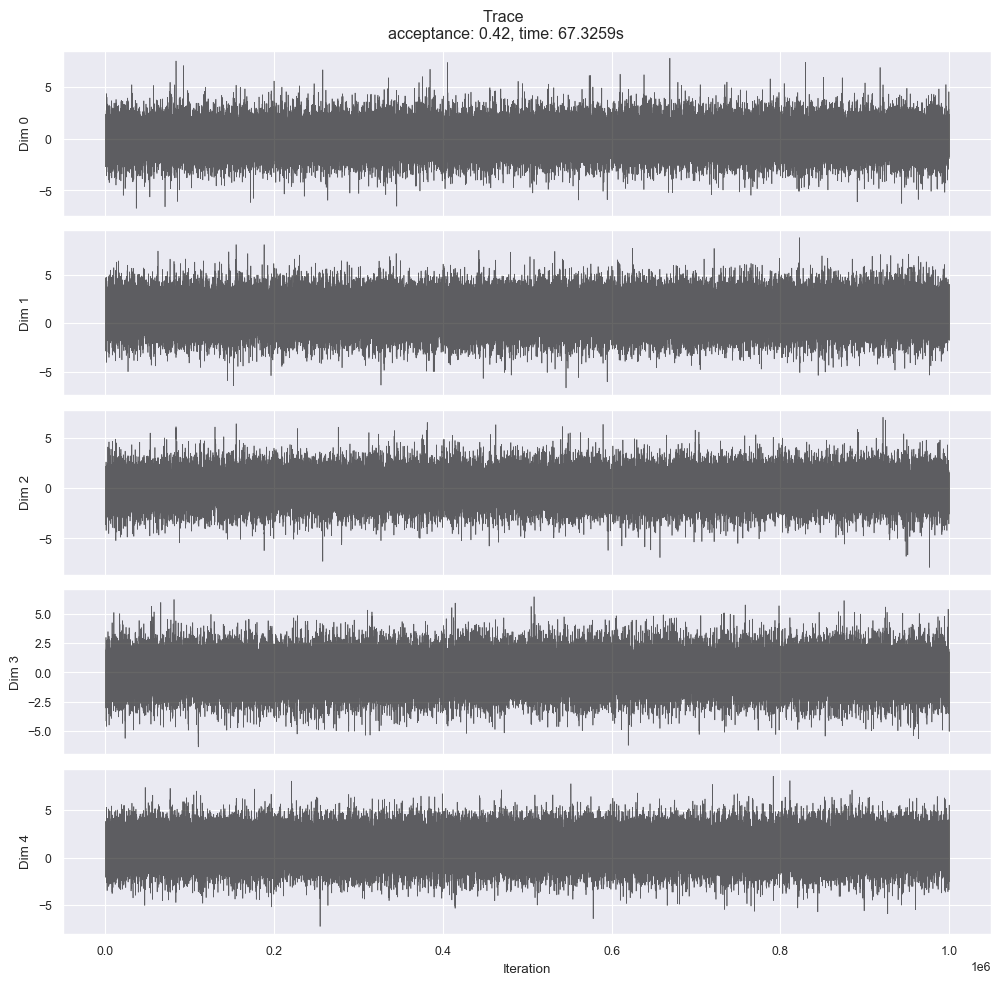

Time elapsed: 67.32590216599783 for number of samples: 1000000.0
Finished Sampling


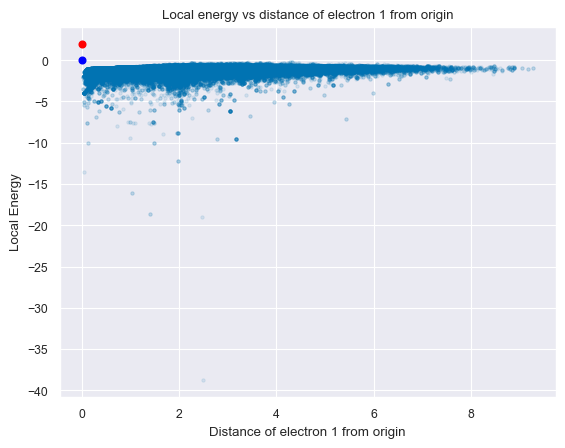

local energy: [-0.76549738 -0.76549738 -0.76549738 ... -0.93957585 -0.93957585
 -1.04857358]
Expected Energy: -1.0932397021040925


<Figure size 800x600 with 0 Axes>

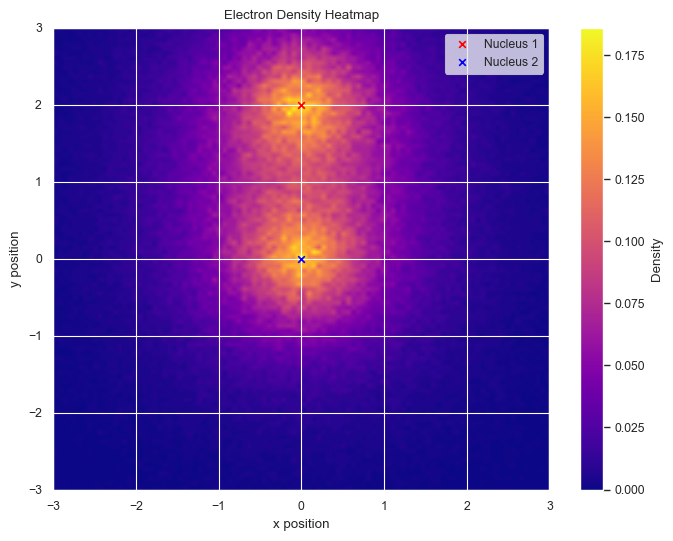

In [ ]:
"""
Simulation of the hydrogen molecule using variational Monte Carlo methods.
Louis Liu 28/11
"""
import numpy as np
from modules.helpers import hydrogen_molecule_helpers as hlp
from modules.differentiators import double_central_difference
from modules.function_sampling import metropolis_hastings, MALA
from modules.minimisers import hydrogen_molecule_minimisers as min
import matplotlib.pyplot as plt
eps = 1e-15


class h2_wavefunction:
    def __init__(self, thetas: np.ndarray, q1: np.ndarray, q2: np.ndarray):
        """
        Constructor
        Parameters:
            theta (np.ndarray): Variational parameters [theta1, theta2, theta3].
            q1 (np.ndarray): Position of the first nucleus.
            q2 (np.ndarray): Position of the second nucleus.
        """
        q1, q2 = np.array(q1), np.array(q2)
        if len(q1.shape) == 1:
            q1, q2 = np.asarray([q1]), np.asarray([q2])

        self.f = hlp.anstatz(thetas, q1, q2)
        self._thetas = thetas
        self._q1 = q1
        self._q2 = q2

    def psi(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The value of the trial wavefunction at the given position(s)
        """
        return self.f(r1, r2)

    def probability_density(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The probability density of the trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The probability density at the given position(s)
        """
        return np.abs(self.f(r1, r2))**2

    def theta(self) -> np.ndarray:
        """
        Returns the theta parameter of the wavefunction
        Returns:
            float: the value of theta for the current wavefunction
        """
        return self._thetas

    def local_energy(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray:
        """
        The local energy of the hydrogen molecule trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """

        r1, r2 = np.asarray(r1), np.asarray(r2)
        #  reformat
        if len(r1.shape) == 1:
            r1, r2 = np.asarray([r1]), np.asarray([r2])

        q1 = self._q1
        q2 = self._q2

        #  function to fix r2
        def f_r1(r1):
            return self.psi(r1, r2)

        #  function to fix r1
        def f_r2(r2):
            return self.psi(r1, r2)

        d2f_r1 = double_central_difference(
            f_r1, r1, h=[1e-5, 1e-5, 1e-5], order=8)

        d2f_r2 = double_central_difference(
            f_r2, r2, h=[1e-5, 1e-5, 1e-5], order=8)

        kinetic = - 0.5 / \
            self.psi(r1, r2) * (np.sum(d2f_r1, axis=1) +
                                np.sum(d2f_r2, axis=1))

        #  computes r and subtracts them
        def d(a, b): return np.sqrt(np.sum((a - b)**2, axis=1))

        r1q1, r1q2 = d(r1, q1), d(r1, q2)
        r2q1, r2q2 = d(r2, q1), d(r2, q2)
        r12 = d(r1, r2)
        q1q2 = d(q1, q2)

        potential = - (1/r1q1 + 1/r1q2 + 1/r2q1 + 1/r2q2) \
            + (1/r12) \
            + (1/q1q2)

        return kinetic + potential

    def E_exp(self, r1, r2):
        """
        The energy expecation value of the hydrogen molecule trial wavefunction at given coordinates
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """
        r1, r2 = np.asarray(r1), np.asarray(r2)
        E_ls = self.local_energy(r1, r2)
        return np.mean(E_ls,)


def test_samples():
    q1 = [0, 2, 0]
    q2 = [0, 0, 0]
    wf = h2_wavefunction(thetas=[1., 1., 1.], q1=q1, q2=q2)

    def wrapper(coords):
        coords = np.asarray(coords)
        r1 = coords[:, 0:3]
        r2 = coords[:, 3:6]

        return wf.probability_density(r1, r2)

    def wrapper_grad(coords):
        from modules.differentiators import central_difference

        coords = np.asarray(coords)
        grad = central_difference(wrapper, coords, h=[1e-4]*6, order=2)
        return np.sum(grad, axis=0)

    x_0 = np.ones(6, dtype=float)
    N_s = 1000000
    # samples = MALA(wrapper, wrapper_grad, x_0=x_0, N=N_s, timestep=0.1, xmin=[
    #                -10., xmax=10., detail=True)

    samples = metropolis_hastings(
        wrapper, f_prop='gaussian', x_0=x_0, xmax=10., xmin=-10., N=N_s, kwrgs={
            'sigma': 0.7}, detail=True)

    print('Finished Sampling')

    r1, r2 = samples[:, 0:3], samples[:, 3:6]
    E_l = wf.local_energy(r1=r1, r2=r2)

    plt.scatter(np.linalg.norm(r1, axis=1), E_l, marker='.', alpha=0.1)
    plt.plot(0, q1[1], 'ro', label='Nucleus 1')
    plt.plot(0, q2[1], 'bo', label='Nucleus 2')
    plt.xlabel("Distance of electron 1 from origin")
    plt.ylabel("Local Energy")
    plt.title("Local energy vs distance of electron 1 from origin")
    plt.show()

    print(f"local energy: {E_l}")
    exp_energy = np.mean(E_l)
    print(f"Expected Energy: {exp_energy}")

    hlp.plot_samples(
        r1, r2, q1=q1, q2=q2, xlim=[-3, 3], ylim=[-3, 3], seaborn=False)
    plt.show()


def test_minimiser():
    q1 = [0, 0, 2]
    q2 = [0, 0, 0]

    minimiser = min.gradient_descent

    thetas_0 = [1.] * 3  #  for minimiser
    theta_min, E_min = minimiser(q1, q2, x_0=thetas_0,
                                 alpha=0.02, stop_tol=None, N_s=10000, detail=True, max_iter=100)

    # theta_min, E_min = min.simulated_annealing(
    #     q1, q2, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=10000, std=0.05, detail=True)
    print(f"minimum theta: {theta_min}, minimum energy: {E_min}")


def ground_state_energies():
    Ns = 100000
    r_0 = np.linspace(0.1, 4., 100)
    q1 = [0.] * 3
    q2 = [[0., 0., i] for i in r_0]

    energies = []
    count = 0
    for q2_i in q2:
        count += 1
        thetas_0 = [1.]*3  #  for minimiser
        # theta_min, E_min = min.simulated_annealing(
        #     q1, q2_i, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=Ns, std=0.05, detail=False)

        theta_min, E_min = min.gradient_descent(
            q1, q2_i, x_0=thetas_0, alpha=0.02, stop_tol=1e-3, N_s=Ns, detail=False, max_iter=100)
        energies.append(E_min)
        if count % 10 == 0:  #  checkpoint at every 10 steps
            np.savetxt(f"output_{Ns}.txt", [energies, r_0[:len(energies)]])

        print(
            f"iteration: {count}, q2: {q2_i}, minimum theta: {theta_min}, minimum energy: {E_min}")

    np.savetxt(f"output_{Ns}.txt", [energies, r_0[:len(energies)]])
    energies = np.array(energies)
    from scipy.optimize import curve_fit
    f = hlp.V_morse
    p_0 = [0.25, 1.3, 1.4]
    fit, cov = curve_fit(f, r_0, energies, p0=p_0)

    plt.plot(r_0, f(r_0, *fit), label='Morse Potential Fit', color='orange')
    plt.plot(r_0, energies, 'o', label='Data')
    plt.xlabel("Distance between nuclei (a.u.)")
    plt.ylabel("Minimum Energy (a.u.)")
    plt.title("Morse Potential Fit to H2 Minimum Energy")
    plt.legend()
    print(
        f"Fitted Parameters: De= {fit[0]}, a= {fit[1]}, re= {fit[2]} \n errors: {np.sqrt(np.diag(cov))}")


if __name__ == '__main__':
    test_samples()

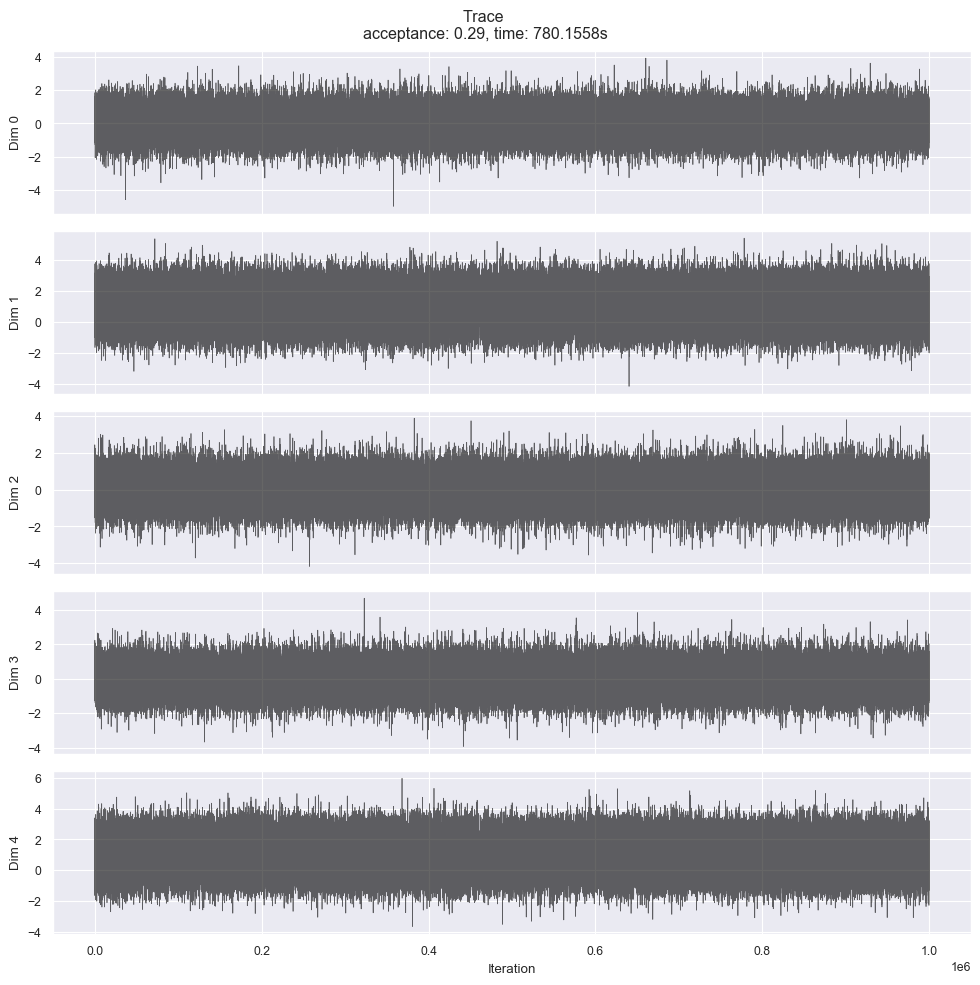

MALA acceptance Rate: 0.29
time elapsed: 780.1557737080002 to iteration 999999
Finished Sampling


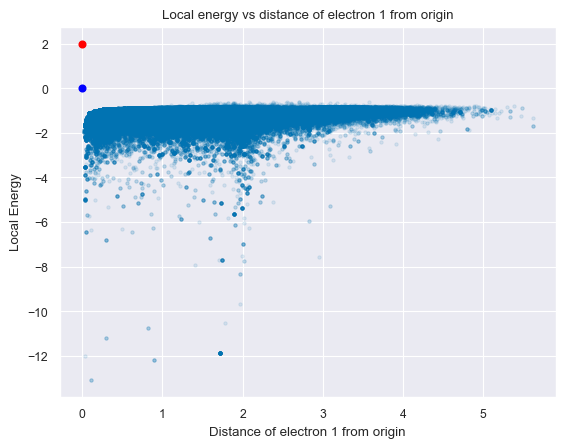

local energy: [-1.3503609  -0.92470228 -0.92470228 ... -1.2873391  -1.1943372
 -1.1943372 ]
Expected Energy: -1.178360734354241


<Figure size 800x600 with 0 Axes>

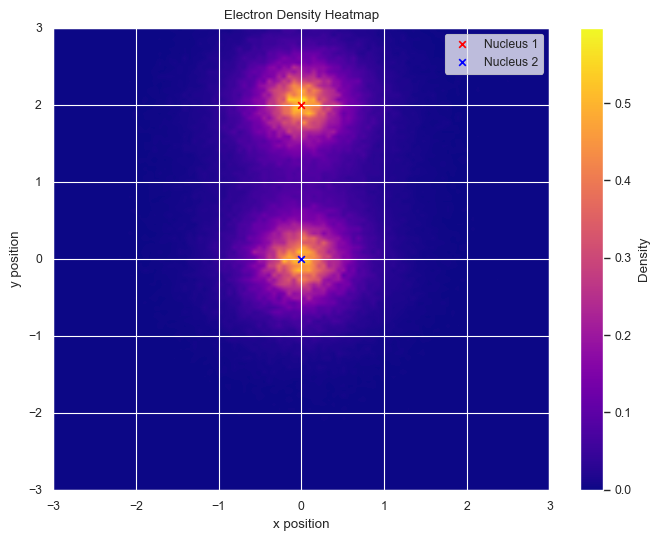

In [ ]:
"""
Simulation of the hydrogen molecule using variational Monte Carlo methods.
Louis Liu 28/11
"""
import numpy as np
from modules.helpers import hydrogen_molecule_helpers as hlp
from modules.differentiators import double_central_difference
from modules.function_sampling import metropolis_hastings, MALA
from modules.minimisers import hydrogen_molecule_minimisers as min
import matplotlib.pyplot as plt
eps = 1e-15


class h2_wavefunction:
    def __init__(self, thetas: np.ndarray, q1: np.ndarray, q2: np.ndarray):
        """
        Constructor
        Parameters:
            theta (np.ndarray): Variational parameters [theta1, theta2, theta3].
            q1 (np.ndarray): Position of the first nucleus.
            q2 (np.ndarray): Position of the second nucleus.
        """
        q1, q2 = np.array(q1), np.array(q2)
        if len(q1.shape) == 1:
            q1, q2 = np.asarray([q1]), np.asarray([q2])

        self.f = hlp.anstatz(thetas, q1, q2)
        self._thetas = thetas
        self._q1 = q1
        self._q2 = q2

    def psi(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The value of the trial wavefunction at the given position(s)
        """
        return self.f(r1, r2)

    def probability_density(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The probability density of the trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The probability density at the given position(s)
        """
        return np.abs(self.f(r1, r2))**2

    def theta(self) -> np.ndarray:
        """
        Returns the theta parameter of the wavefunction
        Returns:
            float: the value of theta for the current wavefunction
        """
        return self._thetas

    def local_energy(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray:
        """
        The local energy of the hydrogen molecule trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """

        r1, r2 = np.asarray(r1), np.asarray(r2)
        #  reformat
        if len(r1.shape) == 1:
            r1, r2 = np.asarray([r1]), np.asarray([r2])

        q1 = self._q1
        q2 = self._q2

        #  function to fix r2
        def f_r1(r1):
            return self.psi(r1, r2)

        #  function to fix r1
        def f_r2(r2):
            return self.psi(r1, r2)

        d2f_r1 = double_central_difference(
            f_r1, r1, h=[1e-5, 1e-5, 1e-5], order=8)

        d2f_r2 = double_central_difference(
            f_r2, r2, h=[1e-5, 1e-5, 1e-5], order=8)

        kinetic = - 0.5 / \
            self.psi(r1, r2) * (np.sum(d2f_r1, axis=1) +
                                np.sum(d2f_r2, axis=1))

        #  computes r and subtracts them
        def d(a, b): return np.sqrt(np.sum((a - b)**2, axis=1))

        r1q1, r1q2 = d(r1, q1), d(r1, q2)
        r2q1, r2q2 = d(r2, q1), d(r2, q2)
        r12 = d(r1, r2)
        q1q2 = d(q1, q2)

        potential = - (1/r1q1 + 1/r1q2 + 1/r2q1 + 1/r2q2) \
            + (1/r12) \
            + (1/q1q2)

        return kinetic + potential

    def E_exp(self, r1, r2):
        """
        The energy expecation value of the hydrogen molecule trial wavefunction at given coordinates
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """
        r1, r2 = np.asarray(r1), np.asarray(r2)
        E_ls = self.local_energy(r1, r2)
        return np.mean(E_ls,)


def test_samples():
    q1 = [0, 2, 0]
    q2 = [0, 0, 0]
    wf = h2_wavefunction(thetas=[1., 1., 1.], q1=q1, q2=q2)

    def wrapper(coords):
        coords = np.asarray(coords)
        r1 = coords[:, 0:3]
        r2 = coords[:, 3:6]

        return wf.probability_density(r1, r2)

    def wrapper_grad(coords):
        from modules.differentiators import central_difference

        coords = np.asarray(coords)
        grad = central_difference(wrapper, coords, h=[1e-4]*6, order=2)
        return np.sum(grad, axis=0)

    x_0 = np.ones(6, dtype=float)
    N_s = 1000000
    samples = MALA(wrapper, wrapper_grad, x_0=x_0, N=N_s,
                   timestep=0.3, xmin=-10., xmax=10., detail=True)

    # samples = metropolis_hastings(
    #     wrapper, f_prop='gaussian', x_0=x_0, xmax=10., xmin=-10., N=N_s, kwrgs={
    #         'sigma': 0.7}, detail=True)

    print('Finished Sampling')

    r1, r2 = samples[:, 0:3], samples[:, 3:6]
    E_l = wf.local_energy(r1=r1, r2=r2)

    plt.scatter(np.linalg.norm(r1, axis=1), E_l, marker='.', alpha=0.1)
    plt.plot(0, q1[1], 'ro', label='Nucleus 1')
    plt.plot(0, q2[1], 'bo', label='Nucleus 2')
    plt.xlabel("Distance of electron 1 from origin")
    plt.ylabel("Local Energy")
    plt.title("Local energy vs distance of electron 1 from origin")
    plt.show()

    print(f"local energy: {E_l}")
    exp_energy = np.mean(E_l)
    print(f"Expected Energy: {exp_energy}")

    hlp.plot_samples(
        r1, r2, q1=q1, q2=q2, xlim=[-3, 3], ylim=[-3, 3], seaborn=False)
    plt.show()


def test_minimiser():
    q1 = [0, 0, 2]
    q2 = [0, 0, 0]

    minimiser = min.gradient_descent

    thetas_0 = [1.] * 3  #  for minimiser
    theta_min, E_min = minimiser(q1, q2, x_0=thetas_0,
                                 alpha=0.02, stop_tol=None, N_s=10000, detail=True, max_iter=100)

    # theta_min, E_min = min.simulated_annealing(
    #     q1, q2, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=10000, std=0.05, detail=True)
    print(f"minimum theta: {theta_min}, minimum energy: {E_min}")


def ground_state_energies():
    Ns = 100000
    r_0 = np.linspace(0.1, 4., 100)
    q1 = [0.] * 3
    q2 = [[0., 0., i] for i in r_0]

    energies = []
    count = 0
    for q2_i in q2:
        count += 1
        thetas_0 = [1.]*3  #  for minimiser
        # theta_min, E_min = min.simulated_annealing(
        #     q1, q2_i, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=Ns, std=0.05, detail=False)

        theta_min, E_min = min.gradient_descent(
            q1, q2_i, x_0=thetas_0, alpha=0.02, stop_tol=1e-3, N_s=Ns, detail=False, max_iter=100)
        energies.append(E_min)
        if count % 10 == 0:  #  checkpoint at every 10 steps
            np.savetxt(f"output_{Ns}.txt", [energies, r_0[:len(energies)]])

        print(
            f"iteration: {count}, q2: {q2_i}, minimum theta: {theta_min}, minimum energy: {E_min}")

    np.savetxt(f"output_{Ns}.txt", [energies, r_0[:len(energies)]])
    energies = np.array(energies)
    from scipy.optimize import curve_fit
    f = hlp.V_morse
    p_0 = [0.25, 1.3, 1.4]
    fit, cov = curve_fit(f, r_0, energies, p0=p_0)

    plt.plot(r_0, f(r_0, *fit), label='Morse Potential Fit', color='orange')
    plt.plot(r_0, energies, 'o', label='Data')
    plt.xlabel("Distance between nuclei (a.u.)")
    plt.ylabel("Minimum Energy (a.u.)")
    plt.title("Morse Potential Fit to H2 Minimum Energy")
    plt.legend()
    print(
        f"Fitted Parameters: De= {fit[0]}, a= {fit[1]}, re= {fit[2]} \n errors: {np.sqrt(np.diag(cov))}")


if __name__ == '__main__':
    test_samples()